<a href="https://colab.research.google.com/github/AISHWARYAARULSELVAN/IPCV/blob/main/EXP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving right.png to right.png
Saving left.png to left.png
Uploaded files: ['right.png', 'left.png']
Reference shape: (540, 720, 3)
Scene shape: (315, 408, 3)

STEP 1: FEATURE DETECTION
Reference keypoints: 1000
Scene keypoints: 999


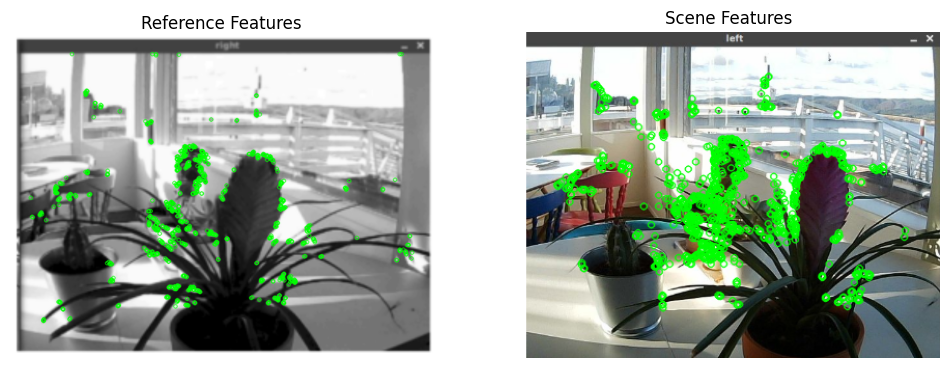


STEP 2: FEATURE MATCHING
Good matches: 48


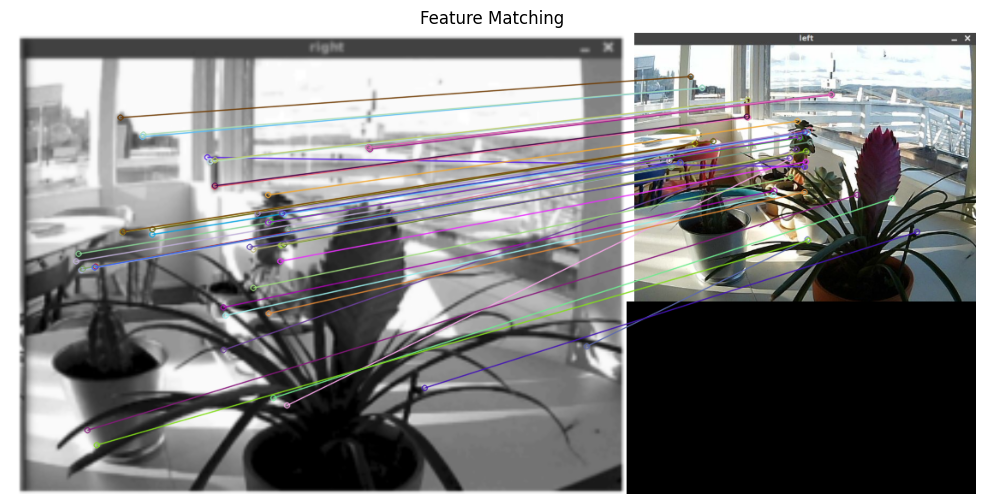


STEP 3: HOMOGRAPHY
Homography matrix:
 [[ 5.46082329e-01  4.69087025e-03 -4.89116006e+00]
 [ 4.32539358e-03  4.08921136e-01  1.12867765e+01]
 [ 9.67454772e-05 -7.58582541e-04  1.00000000e+00]]
Inliers: 26


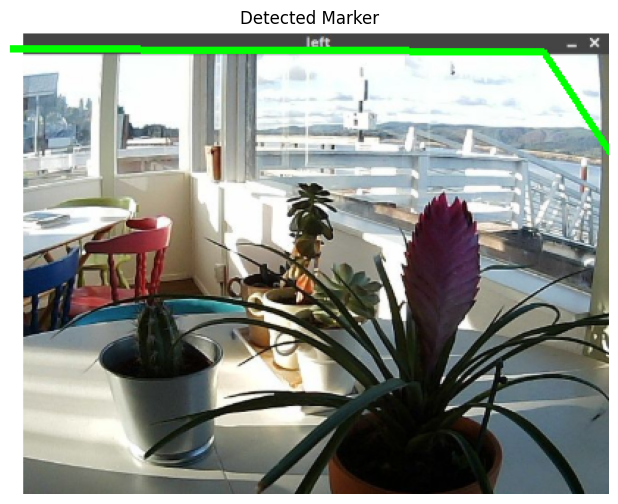


STEP 4: AR CUBE


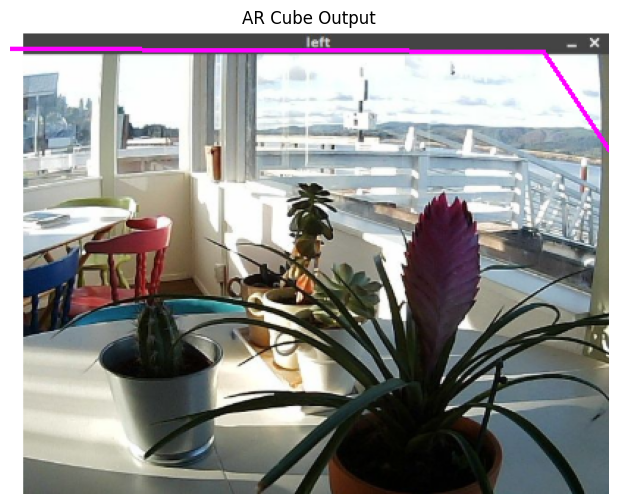


PIPELINE COMPLETE
Reference features: 1000
Scene features: 999
Good matches: 48
Inliers: 26
Homography computed ✔
AR output generated ✔


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import files

# ============================================================
# UPLOAD IMAGES
# ============================================================
uploaded = files.upload()
files_list = list(uploaded.keys())

print("Uploaded files:", files_list)

if len(files_list) < 2:
    print("❌ Please upload 2 images (left & right)")
    exit()

reference_path = files_list[0]
scene_path = files_list[1]

# ============================================================
# LOAD IMAGES
# ============================================================
reference_img = cv2.imread(reference_path)
scene_img = cv2.imread(scene_path)

if reference_img is None or scene_img is None:
    print("❌ Image loading failed")
    exit()

print("Reference shape:", reference_img.shape)
print("Scene shape:", scene_img.shape)

ref_h, ref_w = reference_img.shape[:2]

ref_gray = cv2.cvtColor(reference_img, cv2.COLOR_BGR2GRAY)
scene_gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)

# ============================================================
# STEP 1: FEATURE DETECTION
# ============================================================
print("\nSTEP 1: FEATURE DETECTION")

orb = cv2.ORB_create(nfeatures=1000)

ref_kp, ref_desc = orb.detectAndCompute(ref_gray, None)
scene_kp, scene_desc = orb.detectAndCompute(scene_gray, None)

print("Reference keypoints:", len(ref_kp))
print("Scene keypoints:", len(scene_kp))

ref_kp_img = cv2.drawKeypoints(reference_img, ref_kp, None, color=(0,255,0))
scene_kp_img = cv2.drawKeypoints(scene_img, scene_kp, None, color=(0,255,0))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(ref_kp_img, cv2.COLOR_BGR2RGB))
plt.title("Reference Features")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(scene_kp_img, cv2.COLOR_BGR2RGB))
plt.title("Scene Features")
plt.axis("off")

plt.show()

# ============================================================
# STEP 2: FEATURE MATCHING
# ============================================================
print("\nSTEP 2: FEATURE MATCHING")

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

matches = bf.knnMatch(ref_desc, scene_desc, k=2)

good_matches = []

for m_n in matches:
    if len(m_n) == 2:
        m, n = m_n
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

print("Good matches:", len(good_matches))

match_img = cv2.drawMatches(
    reference_img, ref_kp,
    scene_img, scene_kp,
    good_matches[:100], None, flags=2
)

plt.figure(figsize=(15,6))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title("Feature Matching")
plt.axis("off")
plt.show()

# ============================================================
# STEP 3: HOMOGRAPHY
# ============================================================
print("\nSTEP 3: HOMOGRAPHY")

if len(good_matches) < 4:
    print("❌ Not enough matches")
    exit()

src_pts = np.float32([ref_kp[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
dst_pts = np.float32([scene_kp[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

if H is None:
    print("❌ Homography failed")
    exit()

inliers = np.sum(mask)

print("Homography matrix:\n", H)
print("Inliers:", inliers)

# Draw marker boundary
marker = np.float32([
    [0,0],
    [ref_w,0],
    [ref_w,ref_h],
    [0,ref_h]
]).reshape(-1,1,2)

proj = cv2.perspectiveTransform(marker, H)

scene_marker = scene_img.copy()
scene_marker = cv2.polylines(scene_marker, [np.int32(proj)], True, (0,255,0), 3)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(scene_marker, cv2.COLOR_BGR2RGB))
plt.title("Detected Marker")
plt.axis("off")
plt.show()

# ============================================================
# STEP 4: SIMPLE AR CUBE
# ============================================================
print("\nSTEP 4: AR CUBE")

def draw_cube(img, pts):
    pts = np.int32(pts).reshape(-1,2)

    edges = [(0,1),(1,2),(2,3),(3,0),
             (4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]

    for i,j in edges:
        cv2.line(img, tuple(pts[i]), tuple(pts[j]), (255,0,255), 2)

    return img

# fake 3D cube projection (for lab AR demo)
cube = np.float32([
    [0,0],
    [ref_w,0],
    [ref_w,ref_h],
    [0,ref_h],
    [0,0],
    [ref_w,0],
    [ref_w,ref_h],
    [0,ref_h]
]).reshape(-1,1,2)

cube_proj = cv2.perspectiveTransform(cube, H)

ar_result = draw_cube(scene_img.copy(), cube_proj)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(ar_result, cv2.COLOR_BGR2RGB))
plt.title("AR Cube Output")
plt.axis("off")
plt.show()

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)
print("Reference features:", len(ref_kp))
print("Scene features:", len(scene_kp))
print("Good matches:", len(good_matches))
print("Inliers:", int(inliers))
print("Homography computed ✔")
print("AR output generated ✔")
print("="*60)